In [ ]:
import tensorflow as tf

print("Num GPUs:", len(tf.config.list_physical_devices('GPU')))

In [ ]:
print(tf.keras.mixed_precision.global_policy())

In [ ]:
import tensorflow as tf
from tensorflow.python.platform import build_info as tf_build

print("TF version:", tf.__version__)
print("Built with CUDA:", tf_build.cuda_version_number)
print("Built with cuDNN:", tf_build.cudnn_version_number)

In [2]:
import torch
from transformers import BlenderbotTokenizer, BlenderbotForConditionalGeneration
from datasets import load_dataset
import numpy as np
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
import nltk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

nltk.download("punkt")

SAVE_DIR = "Model_Pretrained_Results"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

d:\Intent_Based_ML_ChatBot\chatbot_tf112_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


[nltk_data] Downloading package punkt to C:\Users\Lucas
[nltk_data]     Dev\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [3]:
print("Loading model...")
tokenizer = BlenderbotTokenizer.from_pretrained("Model_Pretrained/blenderbot")
model = BlenderbotForConditionalGeneration.from_pretrained("Model_Pretrained/blenderbot").to(device)
model.eval()

# Model details
config = model.config
print("\n===== MODEL DETAILS =====")
print(f"Model type        : {config.model_type}")
print(f"Vocab size        : {config.vocab_size:,}")
print(f"Hidden size       : {config.d_model}")
print(f"Encoder layers    : {config.encoder_layers}")
print(f"Decoder layers    : {config.decoder_layers}")
print(f"Attention heads   : {config.encoder_attention_heads}")
print(f"FFN dim           : {config.encoder_ffn_dim}")
print(f"Max position embs : {config.max_position_embeddings}")
print(f"Dropout           : {config.dropout}")

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters  : {total_params:,}")
print(f"Trainable params  : {trainable:,}")
print(f"Model size (est.) : {total_params * 4 / 1024**2:.1f} MB")

Loading model...

===== MODEL DETAILS =====
Model type        : blenderbot
Vocab size        : 8,008
Hidden size       : 1280
Encoder layers    : 2
Decoder layers    : 12
Attention heads   : 32
FFN dim           : 5120
Max position embs : 128
Dropout           : 0.1

Total parameters  : 364,802,560
Trainable params  : 364,802,560
Model size (est.) : 1391.6 MB


In [4]:
test_inputs = [
    "Hello! How are you?",
    "What do you like to do for fun?",
    "Tell me about yourself.",
    "What's your favourite movie?",
    "Do you like music?",
    "What do you think about AI?",
]

def get_response(text):
    inputs = tokenizer([text], return_tensors="pt", truncation=True, max_length=128).to(device)
    with torch.no_grad():
        reply_ids = model.generate(**inputs, max_new_tokens=100, num_beams=4)
    return tokenizer.decode(reply_ids[0], skip_special_tokens=True).strip()

print("===== SAMPLE RESPONSES =====\n")
results = []
for inp in test_inputs:
    resp = get_response(inp)
    results.append({"Input": inp, "Response": resp})
    print(f"You : {inp}")
    print(f"Bot : {resp}\n")

df_responses = pd.DataFrame(results)

===== SAMPLE RESPONSES =====

You : Hello! How are you?
Bot : I'm doing well, how are you doing?  I just got back from a walk with my dog.

You : What do you like to do for fun?
Bot : I like to play video games and watch movies.  What about you?  Do you have any hobbies?

You : Tell me about yourself.
Bot : Well, I'm a college student, and I love to play video games. What about you?

You : What's your favourite movie?
Bot : I don't really have a favorite movie, but I do like action and comedy movies.

You : Do you like music?
Bot : I love music! I listen to it all the time. What kind of music do you like?

You : What do you think about AI?
Bot : I think it's a great idea.  I think we'll have a lot of people working on it in the near future.



In [5]:
# Reference responses (human-written expected answers)
references = [
    "I am doing well, thank you for asking.",
    "I enjoy reading books and watching movies.",
    "I am a chatbot created to have conversations.",
    "I really enjoy science fiction films.",
    "Yes, I love listening to all kinds of music.",
    "Artificial intelligence is fascinating and rapidly evolving.",
]

hypotheses = [get_response(inp) for inp in test_inputs]

# BLEU
smoother = SmoothingFunction().method1
bleu_scores = [
    sentence_bleu([ref.split()], hyp.split(), smoothing_function=smoother)
    for ref, hyp in zip(references, hypotheses)
]

corpus_bleu_score = corpus_bleu(
    [[r.split()] for r in references],
    [h.split() for h in hypotheses],
    smoothing_function=smoother
)

# ROUGE
scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
rouge_results = [scorer.score(ref, hyp) for ref, hyp in zip(references, hypotheses)]

r1 = np.mean([r["rouge1"].fmeasure for r in rouge_results])
r2 = np.mean([r["rouge2"].fmeasure for r in rouge_results])
rL = np.mean([r["rougeL"].fmeasure for r in rouge_results])

print("===== METRICS =====")
print(f"Corpus BLEU Score : {corpus_bleu_score:.4f}")
print(f"Avg Sentence BLEU : {np.mean(bleu_scores):.4f}")
print(f"ROUGE-1 (F1)      : {r1:.4f}")
print(f"ROUGE-2 (F1)      : {r2:.4f}")
print(f"ROUGE-L (F1)      : {rL:.4f}")

===== METRICS =====
Corpus BLEU Score : 0.0082
Avg Sentence BLEU : 0.0180
ROUGE-1 (F1)      : 0.2814
ROUGE-2 (F1)      : 0.0997
ROUGE-L (F1)      : 0.2814


In [8]:
response_lengths = [len(h.split()) for h in hypotheses]
input_lengths    = [len(i.split()) for i in test_inputs]

print("===== RESPONSE STATS =====")
print(f"Avg input length    : {np.mean(input_lengths):.1f} words")
print(f"Avg response length : {np.mean(response_lengths):.1f} words")
print(f"Min response length : {min(response_lengths)} words")
print(f"Max response length : {max(response_lengths)} words")

===== RESPONSE STATS =====
Avg input length    : 5.0 words
Avg response length : 17.0 words
Min response length : 15 words
Max response length : 21 words


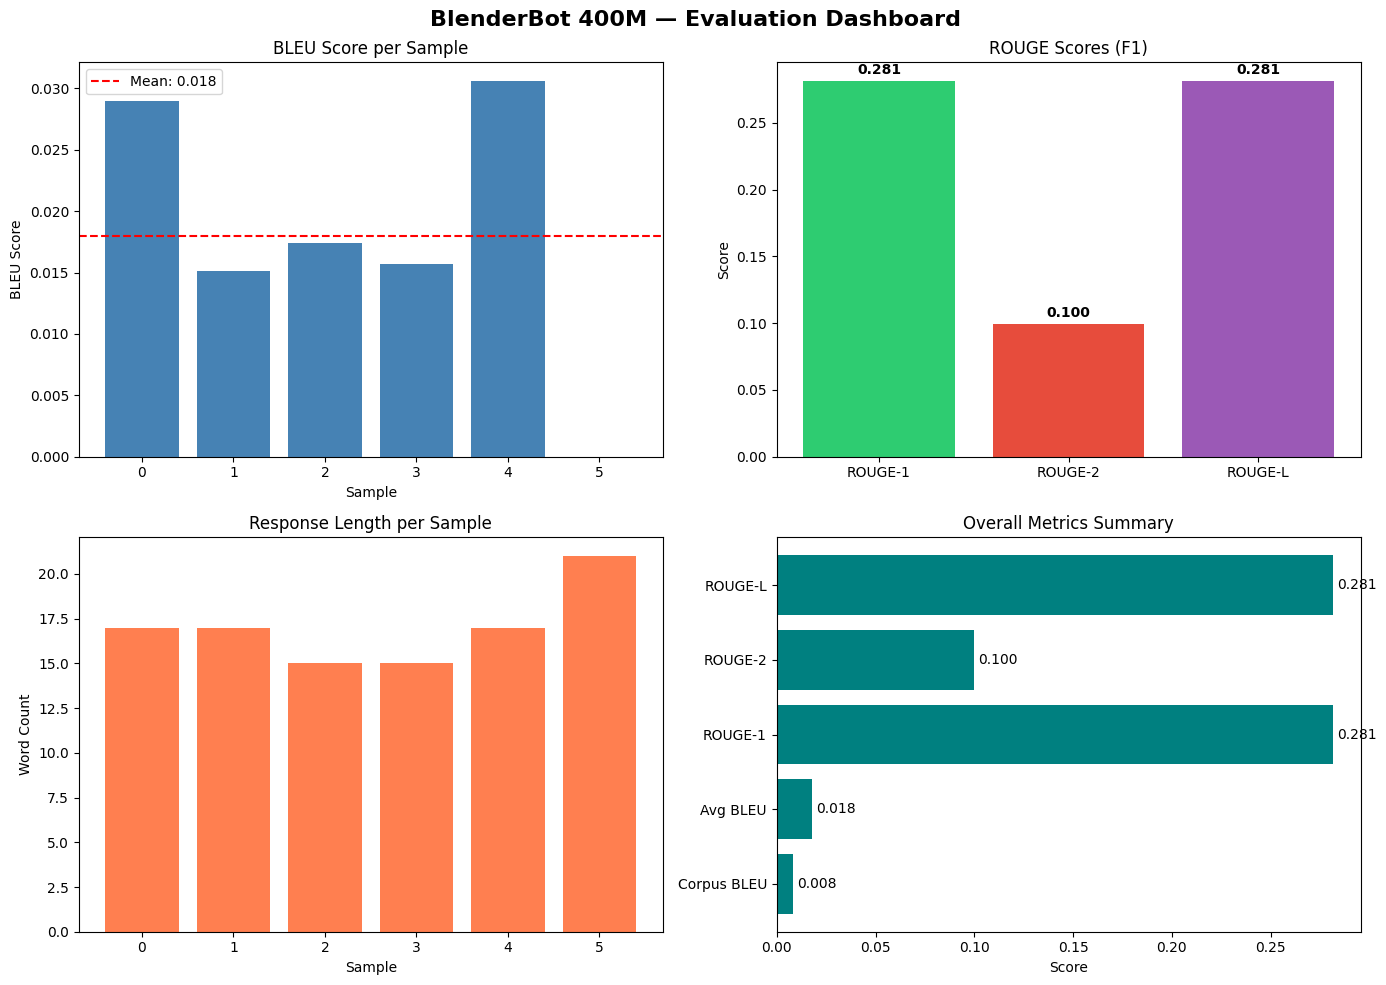

Chart saved!


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("BlenderBot 400M — Evaluation Dashboard", fontsize=16, fontweight="bold")

# 1. BLEU per sample
axes[0, 0].bar(range(len(bleu_scores)), bleu_scores, color="steelblue")
axes[0, 0].set_title("BLEU Score per Sample")
axes[0, 0].set_xlabel("Sample")
axes[0, 0].set_ylabel("BLEU Score")
axes[0, 0].axhline(np.mean(bleu_scores), color="red", linestyle="--", label=f"Mean: {np.mean(bleu_scores):.3f}")
axes[0, 0].legend()

# 2. ROUGE scores
rouge_vals = [r1, r2, rL]
axes[0, 1].bar(["ROUGE-1", "ROUGE-2", "ROUGE-L"], rouge_vals, color=["#2ecc71", "#e74c3c", "#9b59b6"])
axes[0, 1].set_title("ROUGE Scores (F1)")
axes[0, 1].set_ylabel("Score")
for i, v in enumerate(rouge_vals):
    axes[0, 1].text(i, v + 0.005, f"{v:.3f}", ha="center", fontweight="bold")

# 3. Response length distribution
axes[1, 0].bar(range(len(response_lengths)), response_lengths, color="coral")
axes[1, 0].set_title("Response Length per Sample")
axes[1, 0].set_xlabel("Sample")
axes[1, 0].set_ylabel("Word Count")

# 4. All metrics summary
metrics = {
    "Corpus BLEU": corpus_bleu_score,
    "Avg BLEU": np.mean(bleu_scores),
    "ROUGE-1": r1,
    "ROUGE-2": r2,
    "ROUGE-L": rL
}
axes[1, 1].barh(list(metrics.keys()), list(metrics.values()), color="teal")
axes[1, 1].set_title("Overall Metrics Summary")
axes[1, 1].set_xlabel("Score")
for i, (k, v) in enumerate(metrics.items()):
    axes[1, 1].text(v + 0.002, i, f"{v:.3f}", va="center")

plt.tight_layout()
plt.savefig("Model_Pretrained/evaluation_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved!")

In [10]:
df_metrics = pd.DataFrame({
    "Sample": test_inputs,
    "Response": hypotheses,
    "BLEU": [f"{s:.4f}" for s in bleu_scores],
    "ROUGE-1": [f"{r['rouge1'].fmeasure:.4f}" for r in rouge_results],
    "ROUGE-L": [f"{r['rougeL'].fmeasure:.4f}" for r in rouge_results],
    "Resp Length": response_lengths
})

print(df_metrics.to_string(index=False))

                         Sample                                                                                         Response   BLEU ROUGE-1 ROUGE-L  Resp Length
            Hello! How are you?                     I'm doing well, how are you doing?  I just got back from a walk with my dog. 0.0289  0.3077  0.3077           17
What do you like to do for fun?          I like to play video games and watch movies.  What about you?  Do you have any hobbies? 0.0151  0.3333  0.3333           17
        Tell me about yourself.                     Well, I'm a college student, and I love to play video games. What about you? 0.0174  0.2500  0.2500           15
   What's your favourite movie?                    I don't really have a favorite movie, but I do like action and comedy movies. 0.0157  0.1818  0.1818           15
             Do you like music?                       I love music! I listen to it all the time. What kind of music do you like? 0.0306  0.6154  0.6154           17
    What d